# QT-159 Ranking Inference — Probability to Buy

In [1]:
import warnings
warnings.filterwarnings('ignore', message='BigQuery Storage module not found')

import tensorflow as tf
import numpy as np
import pandas as pd
from google.cloud import bigquery
from IPython.display import display, HTML

serve_fn = tf.saved_model.load('Format-Serving').signatures['serving_default']

with open('Format-Serving/assets/customer_id_vocab') as f:
    known_customers = set(int(l.strip()) for l in f)
with open('Format-Serving/assets/product_id_vocab') as f:
    known_products = set(int(l.strip()) for l in f)
with open('Format-Serving/assets/name_vocab') as f:
    known_names = set(l.strip() for l in f)

GCP_PROJECT = 'b2b-recs'
BQ_PROB_TEST = f'{GCP_PROJECT}.raw_data.ternopil_prob_test_v2'
client = bigquery.Client(project=GCP_PROJECT)

print(f'{len(known_customers):,} customers, {len(known_products):,} products, {len(known_names):,} names in vocab')

5,625 customers, 981 products, 946 names in vocab


# Confusion matrix for a single customer 

In [15]:
cust_str = ', '.join(str(c) for c in known_customers)
prod_str = ', '.join(str(p) for p in known_products)

# Pick a random customer (in vocab) with both positive and negative labels
cust_row = client.query(f"""
SELECT customer_id
FROM `{BQ_PROB_TEST}`
WHERE customer_id IN ({cust_str})
  AND product_id IN ({prod_str})
GROUP BY customer_id
HAVING COUNT(DISTINCT label) = 2 AND COUNT(*) >= 5
ORDER BY RAND() LIMIT 1
""").to_dataframe().iloc[0]

cid = int(cust_row['customer_id'])

df = client.query(f"""
SELECT
    CAST(customer_id AS INT64) AS customer_id,
    CAST(product_id AS INT64) AS product_id,
    UNIX_SECONDS(date) AS date_unix,
    cust_value,
    art_name,
    brand_name,
    stratbuy_domain_desc AS category,
    mge_main_cat_desc AS sub_category_v1,
    label
FROM `{BQ_PROB_TEST}`
WHERE customer_id = {cid}
  AND product_id IN ({prod_str})
""").to_dataframe()

print(f'Customer {cid}: {len(df)} interactions ({df["label"].sum()} positive, {(df["label"]==0).sum()} negative)')


result = serve_fn(
    customer_id=tf.constant(df['customer_id'].values, dtype=tf.int64),
    product_id=tf.constant(df['product_id'].values, dtype=tf.int64),
    date=tf.constant(df['date_unix'].values, dtype=tf.int64),
    cust_value=tf.constant(df['cust_value'].values, dtype=tf.float32),
    brand=tf.constant(df['brand_name'].fillna('').values, dtype=tf.string),
    category=tf.constant(df['category'].fillna('').values, dtype=tf.string),
    sub_category_v1=tf.constant(df['sub_category_v1'].fillna('').values, dtype=tf.string),
    name=tf.constant(df['art_name'].fillna('').values, dtype=tf.string),
)

df['prob'] = result['predictions_normalized'].numpy().flatten()

# Sigmoid+MSE doesn't produce a natural decision boundary — evaluate as a
# ranking model: predict top-K as positive where K = number of actual positives.
K = int(df['label'].sum())
threshold = df['prob'].nlargest(K).iloc[-1]
df['pred'] = (df['prob'] >= threshold).astype(int)

tp = ((df['pred'] == 1) & (df['label'] == 1)).sum()
fp = ((df['pred'] == 1) & (df['label'] == 0)).sum()
fn = ((df['pred'] == 0) & (df['label'] == 1)).sum()
tn = ((df['pred'] == 0) & (df['label'] == 0)).sum()

n_neg = tn + fp
prec = tp / (tp + fp) if (tp + fp) > 0 else 0
spec = tn / n_neg if n_neg > 0 else 0

s = 'padding:12px 24px; border:1px solid #ccc; text-align:center; font-size:14px;'
hs = f'{s} background:#eee; font-weight:bold;'

display(HTML(f"""
<h3>Customer {cid}</h3>
<table style="border-collapse:collapse; margin:8px 0;">
  <tr><td style="{hs}"></td><td style="{hs}">Actual +</td><td style="{hs}">Actual &minus;</td></tr>
  <tr><td style="{hs}">Pred +</td>
      <td style="{s} background:#d4edda;"><b>{tp}</b><br><small>+/+</small></td>
      <td style="{s} background:#fff3cd;"><b>{fp}</b><br><small>+/&minus;</small></td></tr>
  <tr><td style="{hs}">Pred &minus;</td>
      <td style="{s} background:#f8d7da;"><b>{fn}</b><br><small>&minus;/+</small></td>
      <td style="{s} background:#d1ecf1;"><b>{tn}</b><br><small>&minus;/&minus;</small></td></tr>
</table>
<p style="font-size:13px; color:#555;">
  Precision: {prec:.1%} ({tp}/{tp+fp} predicted +) &nbsp;|&nbsp;
  Specificity: {spec:.1%} ({tn}/{n_neg} actual &minus;)
</p>
"""))

Customer 330068688001: 45 interactions (9 positive, 36 negative)


,Actual +,Actual −
Pred +,2+/+,7+/−
Pred −,7−/+,29−/−


# Detail table

In [8]:
s = 'padding:4px 10px; border:1px solid #ccc; font-size:13px;'
hs = f'{s} background:#eee;'
hit_s = f'{s} background:#d4edda;'
miss_s = f'{s} background:#f8d7da;'

cols = ['art_name', 'category', 'sub_category_v1', 'label', 'prob', 'pred']
hdr = ''.join(f'<th style="{hs}">{c}</th>' for c in ['Product', 'Category', 'Sub-cat', 'Label', 'Prob', 'Pred'])

rows = ''
for _, r in df.sort_values('prob', ascending=False).iterrows():
    ok = int(r['pred']) == int(r['label'])
    rs = hit_s if ok else miss_s
    rows += (f'<tr><td style="{rs}">{r["art_name"]}</td>'
             f'<td style="{rs}">{r["category"]}</td>'
             f'<td style="{rs}">{r["sub_category_v1"]}</td>'
             f'<td style="{rs}">{int(r["label"])}</td>'
             f'<td style="{rs}">{r["prob"]:.3f}</td>'
             f'<td style="{rs}">{int(r["pred"])}</td></tr>')

display(HTML(f"""
<table style="border-collapse:collapse;"><tr>{hdr}</tr>{rows}</table>
"""))

Product,Category,Sub-cat,Label,Prob,Pred
MPRO ПАКЕТ МАЛ 51МКМ 40*60,DISPOSABLES & TABLEWARE,СУМКИ ДЛЯ ПОКУПОК,1,0.688,1
ТОРЧИН МАЙОНЕЗ ЄВРОП. ДП 300Г,DAIRY,МАРГАРИН,0,0.035,1
ARO ВАТНІ ДИСКИ 120 ШТ,HOME CARE,ЗАСОБИ ГІГІЄНИ ТА ХУСТИНКИ,0,0.034,1
KRONENBOURG ПИВО 0.33Л З/Б,BEERS,ПШЕНИЧНЕ ПИВО,0,0.031,1
MILKA Ш-Д З КР.І ПЕЧ ОРЕО 300Г,CONFECTIONERY & SNACKS,ШОКОЛАД,0,0.029,1
MARS БАТ НУГА/КАРАМ 51Г,CONFECTIONERY & SNACKS,ШОКОЛАД,0,0.026,1
MC СУМІШ СТУДЕНТСЬКА З АР. 1КГ,CONFECTIONERY & SNACKS,СУШЕНІ ГОРІХИ Й НАСІННЯ,0,0.023,1
АКВУЛЯ ПИТНА ВОДА 6 Л,EDIBLE GROCERY,ДИТЯЧЕ ХАРЧУВАННЯ,0,0.023,0
ZEWA DELUXE ТУАЛ.ПАПІР 3Ш 8 РУЛ,HOME CARE,ЗАСОБИ ГІГІЄНИ ТА ХУСТИНКИ,0,0.023,0
BECKY`S ЧІПСИ СМЕТ ЦИБ 120Г,CONFECTIONERY & SNACKS,СОЛОНІ СНЕКИ,0,0.020,0


# Boxplot

60 customers — Precision: mean=31.4%, median=33.3% | Specificity: mean=82.8%, median=83.3%


/var/folders/x1/tws0gtb94h9bs60qvz1l6vyr0000gn/T/ipykernel_75841/257113087.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


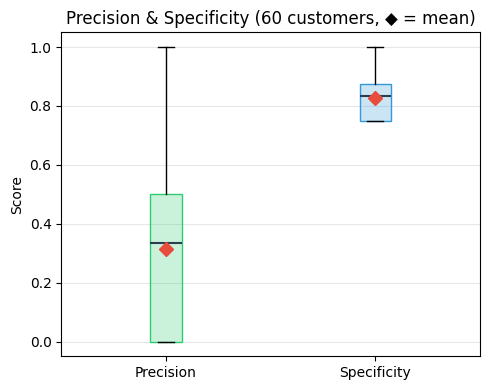

In [4]:
import matplotlib.pyplot as plt

N_CUSTOMERS = 60  # change to 10, 30, etc.

cust_str = ', '.join(str(c) for c in known_customers)
prod_str = ', '.join(str(p) for p in known_products)

# Select random customers that have both labels and ≥5 interactions (in vocab)
custs = client.query(f"""
SELECT customer_id
FROM `{BQ_PROB_TEST}`
WHERE customer_id IN ({cust_str})
  AND product_id IN ({prod_str})
GROUP BY customer_id
HAVING COUNT(DISTINCT label) = 2 AND COUNT(*) >= 5
ORDER BY RAND() LIMIT {N_CUSTOMERS}
""").to_dataframe()

cust_ids = [int(c) for c in custs['customer_id']]
cust_in = ', '.join(str(c) for c in cust_ids)

all_rows = client.query(f"""
SELECT
    CAST(customer_id AS INT64) AS customer_id,
    CAST(product_id AS INT64) AS product_id,
    UNIX_SECONDS(date) AS date_unix,
    cust_value,
    IFNULL(art_name, '') AS art_name,
    IFNULL(brand_name, '') AS brand_name,
    IFNULL(stratbuy_domain_desc, '') AS category,
    IFNULL(mge_main_cat_desc, '') AS sub_category_v1,
    label
FROM `{BQ_PROB_TEST}`
WHERE customer_id IN ({cust_in})
  AND product_id IN ({prod_str})
""").to_dataframe()

# Batch inference
res = serve_fn(
    customer_id=tf.constant(all_rows['customer_id'].values, dtype=tf.int64),
    product_id=tf.constant(all_rows['product_id'].values, dtype=tf.int64),
    date=tf.constant(all_rows['date_unix'].values, dtype=tf.int64),
    cust_value=tf.constant(all_rows['cust_value'].values, dtype=tf.float32),
    brand=tf.constant(all_rows['brand_name'].values, dtype=tf.string),
    category=tf.constant(all_rows['category'].values, dtype=tf.string),
    sub_category_v1=tf.constant(all_rows['sub_category_v1'].values, dtype=tf.string),
    name=tf.constant(all_rows['art_name'].values, dtype=tf.string),
)
all_rows['prob'] = res['predictions_normalized'].numpy().flatten()

# Per-customer precision & specificity
precisions, specificities = [], []
for cid, grp in all_rows.groupby('customer_id'):
    K = int(grp['label'].sum())
    if K == 0:
        continue
    thr = grp['prob'].nlargest(K).iloc[-1]
    pred = (grp['prob'] >= thr).astype(int)
    tp = ((pred == 1) & (grp['label'] == 1)).sum()
    fp = ((pred == 1) & (grp['label'] == 0)).sum()
    tn = ((pred == 0) & (grp['label'] == 0)).sum()
    precisions.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
    specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

print(f'{len(precisions)} customers — Precision: mean={np.mean(precisions):.1%}, '
      f'median={np.median(precisions):.1%} | '
      f'Specificity: mean={np.mean(specificities):.1%}, '
      f'median={np.median(specificities):.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
bp = ax.boxplot(
    [precisions, specificities],
    labels=['Precision', 'Specificity'],
    showmeans=True, meanline=False,
    meanprops=dict(marker='D', markerfacecolor='#e74c3c', markeredgecolor='#e74c3c', markersize=7),
    medianprops=dict(color='#2c3e50', linewidth=1.5),
    patch_artist=True,
)
colors = ['#2ecc71', '#3498db']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color + '40')
    patch.set_edgecolor(color)
ax.set_ylabel('Score')
ax.set_title(f'Precision & Specificity ({len(precisions)} customers, \u25c6 = mean)')
ax.set_ylim(-0.05, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Promo

In [5]:
import random

N_PROMO = 50
TOP_N = 5
BQ_BASE_TABLE = f'{GCP_PROJECT}.raw_data.ternopil_prob_train_v2'

cust_str = ', '.join(str(c) for c in known_customers)

# Random customer with known purchase history
cust_row = client.query(f"""
SELECT customer_id
FROM `{BQ_PROB_TEST}`
WHERE customer_id IN ({cust_str})
GROUP BY customer_id
HAVING COUNT(DISTINCT label) = 2 AND COUNT(*) >= 5
ORDER BY RAND() LIMIT 1
""").to_dataframe().iloc[0]
cid = int(cust_row['customer_id'])

# Personal threshold: score the customer's known interactions, use top-K cutoff
hist = client.query(f"""
SELECT
    CAST(customer_id AS INT64) AS customer_id,
    CAST(product_id AS INT64) AS product_id,
    UNIX_SECONDS(date) AS date_unix, cust_value,
    IFNULL(art_name,'') AS art_name, IFNULL(brand_name,'') AS brand_name,
    IFNULL(stratbuy_domain_desc,'') AS category,
    IFNULL(mge_main_cat_desc,'') AS sub_category_v1, label
FROM `{BQ_PROB_TEST}`
WHERE customer_id = {cid}
""").to_dataframe()

hist_res = serve_fn(
    customer_id=tf.constant(hist['customer_id'].values, dtype=tf.int64),
    product_id=tf.constant(hist['product_id'].values, dtype=tf.int64),
    date=tf.constant(hist['date_unix'].values, dtype=tf.int64),
    cust_value=tf.constant(hist['cust_value'].values, dtype=tf.float32),
    brand=tf.constant(hist['brand_name'].values, dtype=tf.string),
    category=tf.constant(hist['category'].values, dtype=tf.string),
    sub_category_v1=tf.constant(hist['sub_category_v1'].values, dtype=tf.string),
    name=tf.constant(hist['art_name'].values, dtype=tf.string),
)
hist['prob'] = hist_res['predictions_normalized'].numpy().flatten()
K = int(hist['label'].sum())
personal_thr = hist['prob'].nlargest(K).iloc[-1]

# Random promo products from the full vocab (exclude customer's known products)
known_pids = set(hist['product_id'].values)
candidate_pids = list(known_products - known_pids)
random.shuffle(candidate_pids)
promo_pids = candidate_pids[:N_PROMO]
promo_pid_str = ', '.join(str(p) for p in promo_pids)

# Fetch product metadata from the base table
promo = client.query(f"""
SELECT
    CAST(product_id AS INT64) AS product_id,
    ANY_VALUE(art_name) AS art_name,
    ANY_VALUE(brand_name) AS brand_name,
    ANY_VALUE(stratbuy_domain_desc) AS category,
    ANY_VALUE(mge_main_cat_desc) AS sub_category_v1
FROM `{BQ_BASE_TABLE}`
WHERE product_id IN ({promo_pid_str})
GROUP BY 1
""").to_dataframe()

# Score promo products for this customer
ref = hist.iloc[0]
promo_res = serve_fn(
    customer_id=tf.constant([cid] * len(promo), dtype=tf.int64),
    product_id=tf.constant(promo['product_id'].values, dtype=tf.int64),
    date=tf.constant([int(ref['date_unix'])] * len(promo), dtype=tf.int64),
    cust_value=tf.constant([float(ref['cust_value'])] * len(promo), dtype=tf.float32),
    brand=tf.constant(promo['brand_name'].fillna('').values, dtype=tf.string),
    category=tf.constant(promo['category'].fillna('').values, dtype=tf.string),
    sub_category_v1=tf.constant(promo['sub_category_v1'].fillna('').values, dtype=tf.string),
    name=tf.constant(promo['art_name'].fillna('').values, dtype=tf.string),
)
promo['prob'] = promo_res['predictions_normalized'].numpy().flatten()
promo = promo.sort_values('prob', ascending=False).reset_index(drop=True)

n_above = (promo['prob'] >= personal_thr).sum()
print(f'Customer {cid} — {K} known purchases, personal threshold: {personal_thr:.4f}')
print(f'{len(promo)} promo products (from {len(known_products)} vocab): {n_above} above threshold, top-{TOP_N} marked')

# Render table
s = 'padding:4px 10px; border:1px solid #ccc; font-size:13px;'
hs = f'{s} background:#eee;'
top_s = f'{s} background:#d4edda;'   # top-5: green
above_s = f'{s} background:#fff3cd;' # above threshold: yellow

hdr = ''.join(f'<th style="{hs}">{c}</th>'
              for c in ['#', 'Product', 'Brand', 'Category', 'Sub-cat', 'Score', ''])
rows = ''
for i, (_, r) in enumerate(promo.iterrows()):
    is_top = i < TOP_N
    is_above = r['prob'] >= personal_thr
    if is_top:
        rs, badge = top_s, 'TOP 5'
    elif is_above:
        rs, badge = above_s, 'above thr'
    else:
        rs, badge = s, ''
    rows += (f'<tr><td style="{rs}">{i+1}</td>'
             f'<td style="{rs}">{r["art_name"]}</td>'
             f'<td style="{rs}">{r["brand_name"]}</td>'
             f'<td style="{rs}">{r["category"]}</td>'
             f'<td style="{rs}">{r["sub_category_v1"]}</td>'
             f'<td style="{rs}">{r["prob"]:.4f}</td>'
             f'<td style="{rs}"><b>{badge}</b></td></tr>')

display(HTML(f"""
<h3>Customer {cid} — Promo ranking</h3>
<p style="font-size:13px; color:#555;">
  <span style="background:#d4edda; padding:2px 8px;">Top {TOP_N}</span> &nbsp;
  <span style="background:#fff3cd; padding:2px 8px;">Above threshold ({personal_thr:.4f})</span>
</p>
<table style="border-collapse:collapse;"><tr>{hdr}</tr>{rows}</table>
"""))

Customer 370056015701 — 4 known purchases, personal threshold: 0.0204
50 promo products (from 981 vocab): 11 above threshold, top-5 marked


#,Product,Brand,Category,Sub-cat,Score,
1,BARILLA СПАГЕТТІ №5 500Г,BARILLA,EDIBLE GROCERY,МАКАРОННІ ВИРОБИ/ ЛОКШИНА,0.0506,TOP 5
2,МРІЯ ЖЕЛАТИН 25Г,МРІЯ,EDIBLE GROCERY,ВИПІЧКА/ТІСТЕЧКА,0.0433,TOP 5
3,ЧУДО-ЧАДО ПЮРЕ МАН/ЯБЛ/БАН 90Г,ЧУДО ЧАДО,EDIBLE GROCERY,ДИТЯЧЕ ХАРЧУВАННЯ,0.0385,TOP 5
4,CHIPSTER`S ЧІПСИ 130Г,CHIPSTER'S,CONFECTIONERY & SNACKS,СОЛОНІ СНЕКИ,0.0345,TOP 5
5,YARYCH КРЕКЕР З ЦИБУЛЕЮ 180Г,ЯРИЧ,CONFECTIONERY & SNACKS,СОЛОНІ СНЕКИ,0.0336,TOP 5
6,"ARO МОЛОКО 2,5%1000Г",ARO,DAIRY,МОЛОКО,0.0322,above thr
7,ЧУМАК ТОМ.ПАСТА 25% ПІРАМІДКА 70Г,ЧУМАК,EDIBLE GROCERY,СОУСИ ДО СТРАВ,0.0288,above thr
8,"NEMIROFF ГОРІЛКА ШТОФ 0,5",NEMIROFF,SPIRITS,ГОРІЛКА,0.0263,above thr
9,ROSHETTO ВАФ БАТ 34Г,ROSHETTO,CONFECTIONERY & SNACKS,ШОКОЛАД,0.0256,above thr
10,MC СОУС БУРГЕР 515Г,METRO CHEF,EDIBLE GROCERY,ХОЛОДНІ СОУСИ,0.0241,above thr
